# Mamba SSM for WESAD Stress & Affect Detection (60s Window)

This notebook adapts the Mamba audio classifier architecture for **WESAD** (Wearable Stress and Affect Detection), a multimodal physiological time-series dataset.

### Dataset
- 15 subjects, lab study with 3 affective states: **Baseline (0), Stress (1), Amusement (2)**
- Sensors: ECG, EDA, EMG, Respiration, Temperature, 3-axis ACC (chest); BVP, EDA, Temperature, 3-axis ACC (wrist)
- Download from Kaggle: https://www.kaggle.com/datasets/orvile/wesad-wearable-stress-affect-detection-dataset

### Architecture
Same Mamba SSM backbone as the audio classifier, adapted for multivariate physiological signals:
- Input: sliding windows of multi-channel physiological data  
- Mamba SSM replaces mel-spectrogram-based audio features
- Compared against Transformer, LSTM, and 1D CNN baselines

### Citation
Philip Schmidt, Attila Reiss, Robert Duerichen, Claus Marberger and Kristof Van Laerhoven, *"Introducing WESAD, a multimodal dataset for Wearable Stress and Affect Detection"*, ICMI 2018.

## Team Members:
Ana Rodriguez (amrodriguez28@miners.utep.edu)

Darien Booth (djbooth@miners.utep.edu)

## 1. Install Dependencies

In [ ]:
# Core ML stack — pin versions to match Mamba requirements
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip install causal-conv1d==1.4.0
!pip install mamba-ssm==2.2.2 --no-build-isolation

# Data / signal processing
!pip install numpy scipy scikit-learn pandas matplotlib seaborn

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.0/799.0 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 23.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 89.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 82.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 52.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 104.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

## 2. Download WESAD from Kaggle

You need a Kaggle API token (`kaggle.json`). Upload it to Colab or mount Drive and place it at `/root/.kaggle/kaggle.json`.

In [ ]:
# ── Option A: Upload kaggle.json interactively ──────────────────────────────
from google.colab import files
import os

print("Upload your kaggle.json API token:")
uploaded = files.upload()   # select kaggle.json

# os.makedirs('/root/.kaggle', exist_ok=True)
# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle credentials configured.")

Upload your kaggle.json API token:


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


In [ ]:
# ── Download and unzip WESAD ─────────────────────────────────────────────────
!pip install -q kaggle
!kaggle datasets download -d orvile/wesad-wearable-stress-affect-detection-dataset -p /content/wesad_raw
!unzip -q /content/wesad_raw/*.zip -d /content/wesad_dataset
!echo "Done. Dataset structure:"
!ls /content/wesad_dataset

Dataset URL: https://www.kaggle.com/datasets/orvile/wesad-wearable-stress-affect-detection-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.43G/2.43G [00:39<00:00, 66.2MB/s]

Done. Dataset structure:
WESAD


In [ ]:
# mamba-ssm requires an older transformers that still exports
# GreedySearchDecoderOnlyOutput / SampleDecoderOnlyOutput.
# These were removed in transformers >= 4.42.
!pip install -q transformers==4.41.2
import importlib, sys
# Force reload so the freshly installed version is picked up
for mod in list(sys.modules.keys()):
    if mod.startswith('transformers'):
        del sys.modules[mod]
print("transformers pinned to 4.41.2 — ready to import mamba_ssm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 48.7 MB/s eta 0:00:00
transformers pinned to 4.41.2 — ready to import mamba_ssm


## 3. Imports

In [ ]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from mamba_ssm import Mamba

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 4. WESAD Data Loading & Preprocessing

### Signal overview (chest device — RespiBAN)
| Signal | Hz | Description |
|--------|----|-------------|
| ACC    | 700 | 3-axis acceleration |
| ECG    | 700 | Electrocardiogram |
| EDA    | 700 | Electrodermal activity |
| EMG    | 700 | Electromyogram |
| Resp   | 700 | Respiration |
| Temp   | 700 | Body temperature |

Labels: **1=Baseline, 2=Stress, 3=Amusement** (we remap to 0/1/2)

We use a **sliding window** approach (60 s windows, 30 s step) consistent with the WESAD benchmark paper.

In [ ]:
# ── Constants ────────────────────────────────────────────────────────────────
CHEST_FS   = 700          # Hz for all chest signals
WINDOW_SEC = 60           # window length in seconds
STEP_SEC   = 30           # step / stride in seconds
WINDOW_LEN = CHEST_FS * WINDOW_SEC   # samples per window
STEP_LEN   = CHEST_FS * STEP_SEC

# WESAD affective states we keep (drop transient/meditation labels)
LABEL_MAP  = {1: 0, 2: 1, 3: 2}   # baseline→0, stress→1, amusement→2
CLASS_NAMES = ["Baseline", "Stress", "Amusement"]
N_CLASSES  = 3

# Chest signal keys inside the .pkl files
# Each has shape (N, 1) except ACC which is (N, 3)
CHEST_SIGNALS = ["ACC", "ECG", "EDA", "EMG", "Resp", "Temp"]
# ACC contributes 3 channels, rest 1 each → 8 total channels
N_CHANNELS = 8

print(f"Window: {WINDOW_SEC}s  |  Step: {STEP_SEC}s  |  Samples/window: {WINDOW_LEN}")
print(f"Input channels: {N_CHANNELS}  |  Classes: {CLASS_NAMES}")

Window: 60s  |  Step: 30s  |  Samples/window: 42000
Input channels: 8  |  Classes: ['Baseline', 'Stress', 'Amusement']


In [ ]:
def load_subject(pkl_path):
    """
    Load one subject's .pkl file and return
    (signal_array, label_array) where
      signal_array : (N_samples, N_CHANNELS)  float32
      label_array  : (N_samples,)             int  in {0,1,2} or -1 (ignored)
    """
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    chest = data['signal']['chest']

    # Stack channels: ACC(3) + ECG(1) + EDA(1) + EMG(1) + Resp(1) + Temp(1) = 8
    parts = []
    for sig in CHEST_SIGNALS:
        arr = chest[sig]          # shape (N,) or (N,3)
        if arr.ndim == 1:
            arr = arr[:, np.newaxis]
        parts.append(arr)

    signals = np.concatenate(parts, axis=1).astype(np.float32)  # (N, 8)
    labels  = data['label'].squeeze().astype(int)                # (N,)

    # Remap labels: keep only 1/2/3, map to 0/1/2; everything else → -1
    mapped = np.full_like(labels, -1)
    for src, dst in LABEL_MAP.items():
        mapped[labels == src] = dst

    return signals, mapped


def sliding_windows(signals, labels, window_len=WINDOW_LEN, step_len=STEP_LEN):
    """
    Slice a single subject's continuous recording into fixed-length windows.
    A window is kept only if its majority label is one of {0,1,2} (>= 80% purity).

    Returns list of (window_array, label) tuples.
    """
    windows, window_labels = [], []
    N = len(signals)

    for start in range(0, N - window_len + 1, step_len):
        end  = start + window_len
        seg  = signals[start:end]         # (window_len, 8)
        lseg = labels[start:end]          # (window_len,)

        # Find dominant label (excluding -1 noise)
        valid = lseg[lseg >= 0]
        if len(valid) == 0:
            continue
        counts   = np.bincount(valid, minlength=N_CLASSES)
        dom_lbl  = counts.argmax()
        purity   = counts[dom_lbl] / len(lseg)

        if purity >= 0.80:   # 80% of the window must be one class
            windows.append(seg)
            window_labels.append(dom_lbl)

    return windows, window_labels


def load_all_subjects(dataset_root):
    """
    Walk dataset_root, find all subject .pkl files, load and window them.

    Returns:
        X      : list of np.ndarray  (window_len, 8)
        y      : list of int
        groups : list of int  (subject id, for LOSO CV)
    """
    # WESAD pkl files are named like S2/S2.pkl, S3/S3.pkl … S17/S17.pkl
    pkl_files = sorted(glob.glob(os.path.join(dataset_root, '**', 'S*.pkl'),
                                 recursive=True))
    if not pkl_files:
        # Flat layout fallback
        pkl_files = sorted(glob.glob(os.path.join(dataset_root, 'S*.pkl')))

    print(f"Found {len(pkl_files)} subject files.")

    X, y, groups = [], [], []

    for subj_id, pkl_path in enumerate(pkl_files):
        print(f"  Loading {os.path.basename(pkl_path)} …", end=' ')
        signals, labels = load_subject(pkl_path)
        wins, lbls = sliding_windows(signals, labels)
        print(f"{len(wins)} windows")

        X.extend(wins)
        y.extend(lbls)
        groups.extend([subj_id] * len(wins))

    print(f"\nTotal windows: {len(X)}")
    print(f"Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

    return X, y, groups

In [ ]:
# ── Adjust this path to wherever the dataset was extracted ──────────────────
DATASET_ROOT = "/content/wesad_dataset"

X_all, y_all, groups_all = load_all_subjects(DATASET_ROOT)

X_all      = np.array(X_all,      dtype=np.float32)   # (N_windows, window_len, 8)
y_all      = np.array(y_all,      dtype=np.int64)
groups_all = np.array(groups_all, dtype=np.int64)

print(f"\nX shape : {X_all.shape}")
print(f"y shape : {y_all.shape}")

Found 15 subject files.
  Loading S10.pkl … 71 windows
  Loading S11.pkl … 70 windows
  Loading S13.pkl … 70 windows
  Loading S14.pkl … 70 windows
  Loading S15.pkl … 71 windows
  Loading S16.pkl … 72 windows
  Loading S17.pkl … 72 windows
  Loading S2.pkl … 67 windows
  Loading S3.pkl … 68 windows
  Loading S4.pkl … 68 windows
  Loading S5.pkl … 70 windows
  Loading S6.pkl … 70 windows
  Loading S7.pkl … 70 windows
  Loading S8.pkl … 70 windows
  Loading S9.pkl … 70 windows

Total windows: 1049
Label distribution: {np.int64(0): np.int64(570), np.int64(1): np.int64(313), np.int64(2): np.int64(166)}

X shape : (1049, 42000, 8)
y shape : (1049,)


## 5. Down-sampling (optional speedup)

700 Hz × 60 s = **42 000 time steps** per window — very long for an SSM. We optionally downsample to reduce sequence length while preserving signal content. Physiological signals like EDA and temperature are low-frequency; ECG still resolves R-peaks at 100 Hz.

In [ ]:
from scipy.signal import decimate

DOWNSAMPLE_FACTOR = 7    # 700 Hz → 100 Hz  (sequence length: 42000 → 6000)

def downsample_windows(X, factor):
    """Decimate along the time axis (axis=1)."""
    # decimate expects (N,) or (N,C) — process channel by channel
    N, T, C = X.shape
    T_new   = T // factor
    X_ds    = np.zeros((N, T_new, C), dtype=np.float32)
    for i in range(N):
        for c in range(C):
            ds = decimate(X[i, :, c], factor, zero_phase=True)
            X_ds[i, :, c] = ds[:T_new]
    return X_ds

print(f"Downsampling by factor {DOWNSAMPLE_FACTOR}: "
      f"{X_all.shape[1]} → {X_all.shape[1]//DOWNSAMPLE_FACTOR} time steps per window")

X_ds = downsample_windows(X_all, DOWNSAMPLE_FACTOR)
print(f"Downsampled X shape: {X_ds.shape}")

Downsampling by factor 7: 42000 → 6000 time steps per window
Downsampled X shape: (1049, 6000, 8)


## 6. Dataset & DataLoader

In [ ]:
class WESADDataset(Dataset):
    """
    Wraps pre-sliced windows for PyTorch.
    Each item: (window, label) where
      window : FloatTensor (T, C)   — T time steps, C channels
      label  : LongTensor  scalar
    """
    def __init__(self, X, y, scaler=None, fit_scaler=False):
        """
        Args:
            X          : np.ndarray (N, T, C)
            y          : np.ndarray (N,)
            scaler     : sklearn StandardScaler (optional, applied per-channel)
            fit_scaler : if True, fit scaler on this split's data
        """
        N, T, C = X.shape
        if scaler is not None:
            # Reshape to (N*T, C), scale, reshape back
            flat = X.reshape(-1, C)
            if fit_scaler:
                flat = scaler.fit_transform(flat)
            else:
                flat = scaler.transform(flat)
            X = flat.reshape(N, T, C)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(X_train, y_train, X_val, y_val, batch_size=16):
    scaler = StandardScaler()
    train_ds = WESADDataset(X_train, y_train, scaler=scaler, fit_scaler=True)
    val_ds   = WESADDataset(X_val,   y_val,   scaler=scaler, fit_scaler=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  pin_memory=True, num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, pin_memory=True, num_workers=2)
    return train_loader, val_loader, scaler

## 7. Model Definitions

All four models share the same interface:
- **Input**: `(B, T, C)` — batch of multi-channel physiological windows
- **Output**: `(B, N_CLASSES)` — class logits

In [ ]:
# ─── Mamba SSM Classifier ────────────────────────────────────────────────────
class MambaClassifier(nn.Module):
    """
    State-Space Model (Mamba) for physiological time-series classification.

    Architecture:
        Linear projection → Mamba SSM → LayerNorm → Dropout → GlobalMaxPool → FC

    Why Mamba for physiological signals?
        - Long-range dependencies across 60s windows (slow rhythms like EDA)
        - Linear-time complexity vs O(T²) for Transformers
        - Selective state spaces can ignore irrelevant sub-sequences
    """
    def __init__(self, in_channels=N_CHANNELS, d_model=64,
                 n_classes=N_CLASSES, d_state=16, d_conv=4, expand=2):
        super().__init__()

        self.input_proj = nn.Linear(in_channels, d_model)

        self.mamba = Mamba(
            d_model=d_model,
            d_state=d_state,
            d_conv=d_conv,
            expand=expand
        )

        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.3)
        self.pool    = nn.AdaptiveMaxPool1d(1)
        self.fc      = nn.Linear(d_model, n_classes)

    def forward(self, x):
        # x: (B, T, C)
        x = self.input_proj(x)          # (B, T, d_model)
        x = self.mamba(x)               # (B, T, d_model)
        x = self.norm(x)
        x = self.dropout(x)
        x = x.transpose(1, 2)          # (B, d_model, T)
        x = self.pool(x).squeeze(-1)   # (B, d_model)
        return self.fc(x)              # (B, n_classes)


# ─── Transformer Classifier ───────────────────────────────────────────────────
class TransformerClassifier(nn.Module):
    """
    Standard Transformer encoder for comparison.
    O(T²) attention — expensive on very long sequences.
    We use a small nhead=4 to keep memory manageable at 6000 time steps.
    """
    def __init__(self, in_channels=N_CHANNELS, d_model=64,
                 n_classes=N_CLASSES, nhead=4, num_layers=2, max_len=8192):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        self.pos_enc    = nn.Embedding(max_len, d_model)

        encoder_layer   = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4, dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                  num_layers=num_layers)
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.3)
        self.pool    = nn.AdaptiveMaxPool1d(1)
        self.fc      = nn.Linear(d_model, n_classes)

    def forward(self, x):
        # x: (B, T, C)
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)  # (1, T)
        x   = self.input_proj(x) + self.pos_enc(pos)         # (B, T, d_model)
        x   = self.transformer(x)
        x   = self.norm(x)
        x   = self.dropout(x)
        x   = x.transpose(1, 2)          # (B, d_model, T)
        x   = self.pool(x).squeeze(-1)   # (B, d_model)
        return self.fc(x)


# ─── Bidirectional LSTM Classifier ───────────────────────────────────────────
class LSTMClassifier(nn.Module):
    """
    Bi-directional LSTM. Classic RNN baseline.
    Physiological signals have clear temporal direction (heart rate trend,
    EDA rise), so bidirectional context is a meaningful inductive bias.
    """
    def __init__(self, in_channels=N_CHANNELS, d_model=64,
                 n_classes=N_CLASSES, hidden=128, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)

        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2,
            bidirectional=True
        )
        self.norm    = nn.LayerNorm(hidden * 2)
        self.dropout = nn.Dropout(0.3)
        self.pool    = nn.AdaptiveMaxPool1d(1)
        self.fc      = nn.Linear(hidden * 2, n_classes)

    def forward(self, x):
        x = self.input_proj(x)          # (B, T, d_model)
        x, _ = self.lstm(x)             # (B, T, hidden*2)
        x = self.norm(x)
        x = self.dropout(x)
        x = x.transpose(1, 2)          # (B, hidden*2, T)
        x = self.pool(x).squeeze(-1)   # (B, hidden*2)
        return self.fc(x)


# ─── 1D CNN Classifier ────────────────────────────────────────────────────────
class CNNClassifier(nn.Module):
    """
    Hierarchical 1D CNN over the channel dimension.
    Each Conv1d → BN → ReLU → MaxPool block compresses the time axis.
    Fixed receptive field: captures local temporal features (HRV bursts,
    SCR peaks) but misses global context across 60-second windows.
    """
    def __init__(self, in_channels=N_CHANNELS, n_classes=N_CLASSES):
        super().__init__()

        def conv_block(in_ch, out_ch, kernel=7, pool=4):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel, padding=kernel // 2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.MaxPool1d(pool)
            )

        # Input: (B, C, T) — channel dimension = physiological channels
        self.encoder = nn.Sequential(
            conv_block(in_channels, 64),    # T → T/4
            conv_block(64, 128),            # T/4 → T/16
            conv_block(128, 256),           # T/16 → T/64
        )
        self.dropout = nn.Dropout(0.3)
        self.pool    = nn.AdaptiveMaxPool1d(1)
        self.fc      = nn.Linear(256, n_classes)

    def forward(self, x):
        # x: (B, T, C)  → permute to (B, C, T) for Conv1d
        x = x.transpose(1, 2)          # (B, C, T)
        x = self.encoder(x)            # (B, 256, T')
        x = self.dropout(x)
        x = self.pool(x).squeeze(-1)   # (B, 256)
        return self.fc(x)

## 8. Training & Evaluation Utilities

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x = x.to(device, non_blocking=True).contiguous()
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss


def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = correct / total
    return acc, np.array(all_preds), np.array(all_labels)


def train_model(model_class, X_train, y_train, X_val, y_val,
                epochs=20, lr=1e-3, batch_size=16):
    """
    Train a model and return (trained_model, val_history).
    """
    train_loader, val_loader, scaler = make_loaders(
        X_train, y_train, X_val, y_val, batch_size=batch_size
    )

    model     = model_class().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Class-balanced loss (stress/amusement may be underrepresented)
    counts    = np.bincount(y_train, minlength=N_CLASSES).astype(float)
    weights   = torch.tensor(1.0 / (counts + 1e-6), dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights)

    history = []
    for epoch in range(epochs):
        loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        acc, _, _ = evaluate(model, val_loader, DEVICE)
        scheduler.step()
        history.append({'epoch': epoch + 1, 'loss': loss, 'val_acc': acc})
        print(f"  Epoch {epoch+1:3d}: loss={loss:.4f}  val_acc={acc:.4f}")

    return model, val_loader, history, scaler

## 9. Simple Train/Val/Test Split

We use a **subject-aware split**: subjects are divided 70/15/15 so no subject appears in both train and test. This prevents data leakage from person-specific physiological patterns.

> For a rigorous benchmark, switch to Leave-One-Subject-Out (LOSO) CV — see **Section 11**.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

def subject_aware_split(X, y, groups, val_frac=0.15, test_frac=0.15, seed=42):
    """
    Split windows so that no subject appears in multiple splits.
    Returns (X_train, y_train, X_val, y_val, X_test, y_test).
    """
    gss = GroupShuffleSplit(n_splits=1, test_size=test_frac + val_frac,
                            random_state=seed)
    train_idx, temp_idx = next(gss.split(X, y, groups))

    # Split temp into val and test
    X_temp, y_temp = X[temp_idx], y[temp_idx]
    g_temp = groups[temp_idx]

    val_frac_adj = val_frac / (val_frac + test_frac)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=1 - val_frac_adj,
                             random_state=seed)
    val_idx, test_idx = next(gss2.split(X_temp, y_temp, g_temp))

    return (X[train_idx], y[train_idx],
            X_temp[val_idx],  y_temp[val_idx],
            X_temp[test_idx], y_temp[test_idx])


X_train, y_train, X_val, y_val, X_test, y_test = subject_aware_split(
    X_ds, y_all, groups_all
)

print(f"Train: {len(y_train)} windows | Val: {len(y_val)} | Test: {len(y_test)}")
print(f"Train class dist : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Val   class dist : {dict(zip(*np.unique(y_val,   return_counts=True)))}")
print(f"Test  class dist : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Train: 698 windows | Val: 141 | Test: 210
Train class dist : {np.int64(0): np.int64(380), np.int64(1): np.int64(207), np.int64(2): np.int64(111)}
Val   class dist : {np.int64(0): np.int64(76), np.int64(1): np.int64(43), np.int64(2): np.int64(22)}
Test  class dist : {np.int64(0): np.int64(114), np.int64(1): np.int64(63), np.int64(2): np.int64(33)}


## 10. Train & Evaluate All Models

In [ ]:
EPOCHS     = 10
BATCH_SIZE = 16
LR         = 1e-3

model_configs = {
    "Mamba":       MambaClassifier,
    "Transformer": TransformerClassifier,
    "LSTM":        LSTMClassifier,
    "CNN":         CNNClassifier,
}

trained_models = {}
all_histories  = {}
test_results   = {}

# Shared test loader (re-created with each model's scaler inside train_model)
for name, ModelClass in model_configs.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")

    model, val_loader, history, scaler = train_model(
        ModelClass, X_train, y_train, X_val, y_val,
        epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE
    )

    # Evaluate on held-out test set using the same scaler
    test_ds     = WESADDataset(X_test, y_test, scaler=scaler, fit_scaler=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                             shuffle=False, pin_memory=True)
    test_acc, preds, labels = evaluate(model, test_loader, DEVICE)

    trained_models[name] = model
    all_histories[name]  = history
    test_results[name]   = {
        'acc': test_acc,
        'preds': preds,
        'labels': labels
    }

    print(f"\n  ► {name} Test Accuracy: {test_acc:.4f}")


  Training: Mamba
  Epoch   1: loss=42.5107  val_acc=0.6596
  Epoch   2: loss=22.0933  val_acc=0.6596
  Epoch   3: loss=14.6243  val_acc=0.6950
  Epoch   4: loss=10.4304  val_acc=0.7376
  Epoch   5: loss=6.9566  val_acc=0.6738
  Epoch   6: loss=5.1429  val_acc=0.7305
  Epoch   7: loss=4.0374  val_acc=0.7092
  Epoch   8: loss=3.0526  val_acc=0.7092
  Epoch   9: loss=2.3455  val_acc=0.7234
  Epoch  10: loss=1.9616  val_acc=0.7376
  Epoch  11: loss=1.6044  val_acc=0.7305
  Epoch  12: loss=1.3581  val_acc=0.7163
  Epoch  13: loss=1.2453  val_acc=0.7234
  Epoch  14: loss=1.1740  val_acc=0.7234
  Epoch  15: loss=1.0793  val_acc=0.7234
  Epoch  16: loss=1.0128  val_acc=0.7234
  Epoch  17: loss=0.9624  val_acc=0.7234
  Epoch  18: loss=0.9355  val_acc=0.7234
  Epoch  19: loss=0.9152  val_acc=0.7234
  Epoch  20: loss=0.9150  val_acc=0.7234

  ► Mamba Test Accuracy: 0.7286

  Training: Transformer
  Epoch   1: loss=50.7207  val_acc=0.3191
  Epoch   2: loss=40.9001  val_acc=0.6383
  Epoch   3: lo

## 11. Results & Visualisation

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*55)
print(f"{'Model':<16}  {'Test Acc':>10}  {'Stress F1':>10}")
print("-"*55)

for name, res in test_results.items():
    from sklearn.metrics import f1_score
    stress_f1 = f1_score(res['labels'], res['preds'],
                         labels=[1], average='macro')
    print(f"{name:<16}  {res['acc']:>10.4f}  {stress_f1:>10.4f}")

print("="*55)


Model               Test Acc   Stress F1
-------------------------------------------------------
Mamba                 0.7286      0.6105
Transformer           0.6143      0.3441
LSTM                  0.6524      0.4272
CNN                   0.7286      0.7400


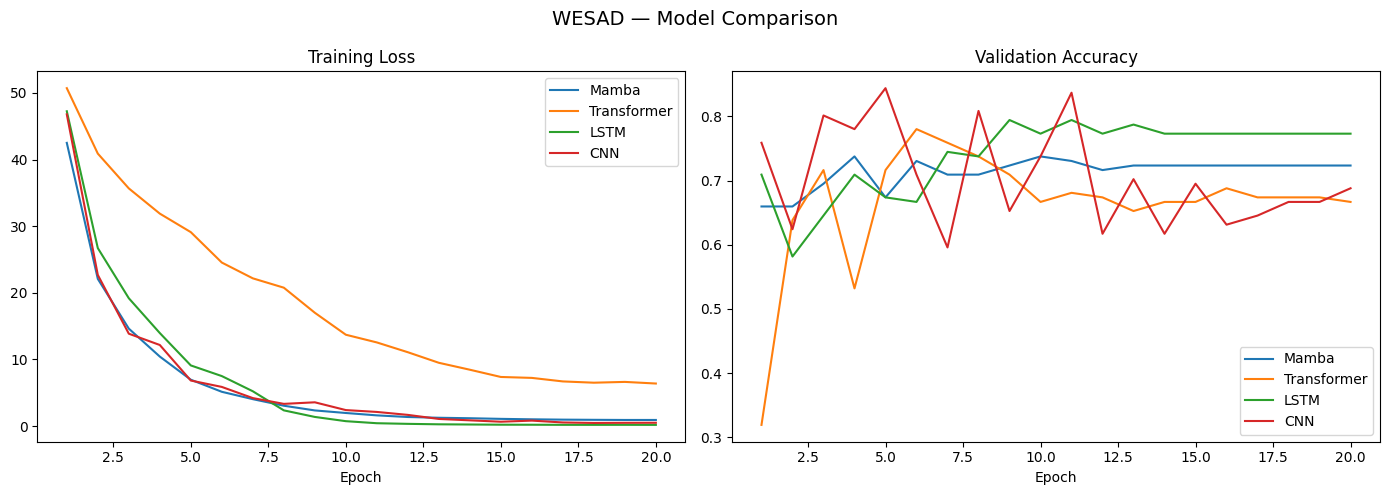

In [ ]:
# ── Learning curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, history in all_histories.items():
    epochs_  = [h['epoch']   for h in history]
    losses   = [h['loss']    for h in history]
    val_accs = [h['val_acc'] for h in history]

    axes[0].plot(epochs_, losses,   label=name)
    axes[1].plot(epochs_, val_accs, label=name)

axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch");  axes[0].legend()
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch");  axes[1].legend()

plt.suptitle("WESAD — Model Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("wesad_learning_curves.png", dpi=150)
plt.show()

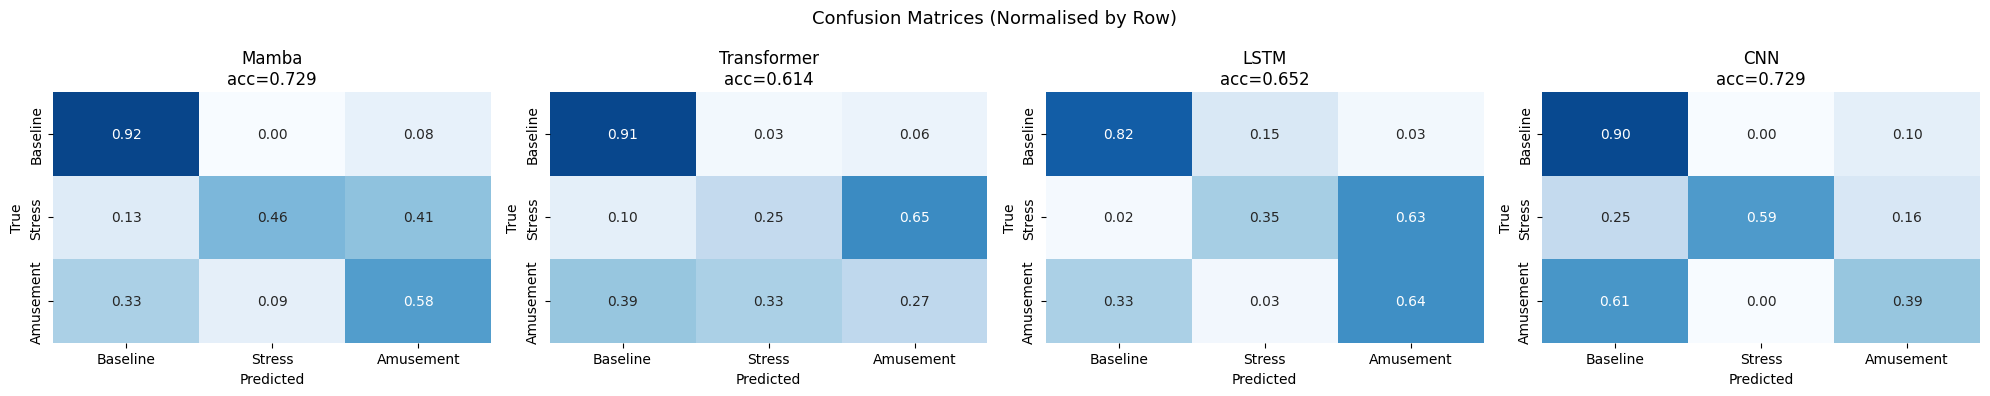

In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(test_results), figsize=(5 * len(test_results), 4))

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(res['labels'], res['preds'], labels=[0, 1, 2])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_pct, annot=True, fmt='.2f', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', vmin=0, vmax=1, cbar=False)
    ax.set_title(f"{name}\nacc={res['acc']:.3f}")
    ax.set_xlabel("Predicted");  ax.set_ylabel("True")

plt.suptitle("Confusion Matrices (Normalised by Row)", fontsize=13)
plt.tight_layout()
plt.savefig("wesad_confusion_matrices.png", dpi=150)
plt.show()

In [ ]:
# ── Full classification reports ───────────────────────────────────────────────
for name, res in test_results.items():
    print(f"\n{'-'*40}")
    print(f"  {name} — Classification Report")
    print(f"{'-'*40}")
    print(classification_report(
        res['labels'], res['preds'],
        target_names=CLASS_NAMES, digits=4
    ))


----------------------------------------
  Mamba — Classification Report
----------------------------------------
              precision    recall  f1-score   support

    Baseline     0.8468    0.9211    0.8824       114
      Stress     0.9062    0.4603    0.6105        63
   Amusement     0.3519    0.5758    0.4368        33

    accuracy                         0.7286       210
   macro avg     0.7016    0.6524    0.6432       210
weighted avg     0.7868    0.7286    0.7308       210


----------------------------------------
  Transformer — Classification Report
----------------------------------------
              precision    recall  f1-score   support

    Baseline     0.8455    0.9123    0.8776       114
      Stress     0.5333    0.2540    0.3441        63
   Amusement     0.1579    0.2727    0.2000        33

    accuracy                         0.6143       210
   macro avg     0.5123    0.4797    0.4739       210
weighted avg     0.6438    0.6143    0.6111       210


-